In [2]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import pandas as pd
import librosa

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

## Load dataset

In [3]:
path = "../pitch/GPS_cmd_16k_renamed_pyin_avg_by_word_user.csv"
df = pd.read_csv(path)
df

,filepaths,users,genders,words,f0
0,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F001,F,academia,207
1,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F001,F,academia,207
2,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F001,F,academia,207
3,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F001,F,academia,207
4,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F001,F,academia,207
...,...,...,...,...,...
3995,/home/jovyan/work/OneDrive/Documentos/Doutorad...,M020,M,trabalho,102
3996,/home/jovyan/work/OneDrive/Documentos/Doutorad...,M020,M,trabalho,102
3997,/home/jovyan/work/OneDrive/Documentos/Doutorad...,M020,M,trabalho,102
3998,/home/jovyan/work/OneDrive/Documentos/Doutorad...,M020,M,trabalho,102


In [4]:
df['filepaths'][0]

'/home/jovyan/work/OneDrive/Documentos/Doutorado/dataset/GPS_cmd_16k_renamed/academia_F001_001.wav'

users f/m = 20 -  train: 14, val: 2, test: 4

Test: F017 F018 F019 F020 M017 M018 M019 M020

Val: F015 F016 M015 M016

Train: restante

In [5]:
df_test = df[(df["users"] == "F017") | (df["users"] == "F018") | (df["users"] == "F019") | (df["users"] == "F020") \
| (df["users"] == "M017") | (df["users"] == "M018") | (df["users"] == "M019") | (df["users"] == "M020")].reset_index(drop=True)

In [6]:
df_val = df[(df["users"] == "F015") | (df["users"] == "F016") | (df["users"] == "M015") | (df["users"] == "M016")].reset_index(drop=True)

In [7]:
df_diff = df.merge(df_test, how='outer', indicator=True).loc[lambda x : x['_merge'] == 'left_only'].drop(columns=['_merge'])

In [8]:
df_train = df_diff.merge(df_val, how='outer', indicator=True).loc[lambda x : x['_merge'] == 'left_only'].drop(columns=['_merge'])

In [9]:
"Train: ", len(df_train), "Val: ", len(df_val), "Test: ", len(df_test)

('Train: ', 2800, 'Val: ', 400, 'Test: ', 800)

In [10]:
def get_files(df):
    files = list(df["filepaths"])
    labels = list(df["words"])
    return files, labels

In [11]:
train_files, train_labels = get_files(df_train)
val_files, val_labels = get_files(df_val)
test_files, test_labels = get_files(df_test)

## Read Dataset

In [12]:
path_1 = df_test["filepaths"][0]

In [13]:
test_file = tf.io.read_file(path_1)
test_audio, _ = tf.audio.decode_wav(contents=test_file)
test_audio.shape

TensorShape([16106, 1])

In [14]:
def decode_audio(audio_binary):
  # Decode WAV-encoded audio files to `float32` tensors, normalized
  # to the [-1.0, 1.0] range. Return `float32` audio and a sample rate.
  audio, _ = tf.audio.decode_wav(contents=audio_binary)
  # Since all the data is single channel (mono), drop the `channels`
  # axis from the array.
  return tf.squeeze(audio, axis=-1)

Defina outra função auxiliar— get_waveform_and_label —que junte tudo:

- A entrada é o nome do arquivo de áudio WAV.
- .
A saída é uma tupla contendo os tensores de áudio e rótulo prontos para aprendizado supervisionado.

In [15]:
def get_waveform_and_label(file_path, label):
  audio_binary = tf.io.read_file(file_path)
  waveform = decode_audio(audio_binary)
  return waveform, label

def get_waveform_and_label_and_filepath(file_path, label):
  audio_binary = tf.io.read_file(file_path)
  waveform = decode_audio(audio_binary)
  return file_path, waveform, label

#### Crie o conjunto de treinamento para extrair os pares de rótulo de áudio:

Crie um tf.data.Dataset com Dataset.from_tensor_slices e Dataset.map , usando get_waveform_and_label definido anteriormente.
Você construirá os conjuntos de validação e teste usando um procedimento semelhante posteriormente.

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels))

val_waveform_ds = val_ds.map(
    map_func=get_waveform_and_label,
    num_parallel_calls=AUTOTUNE)

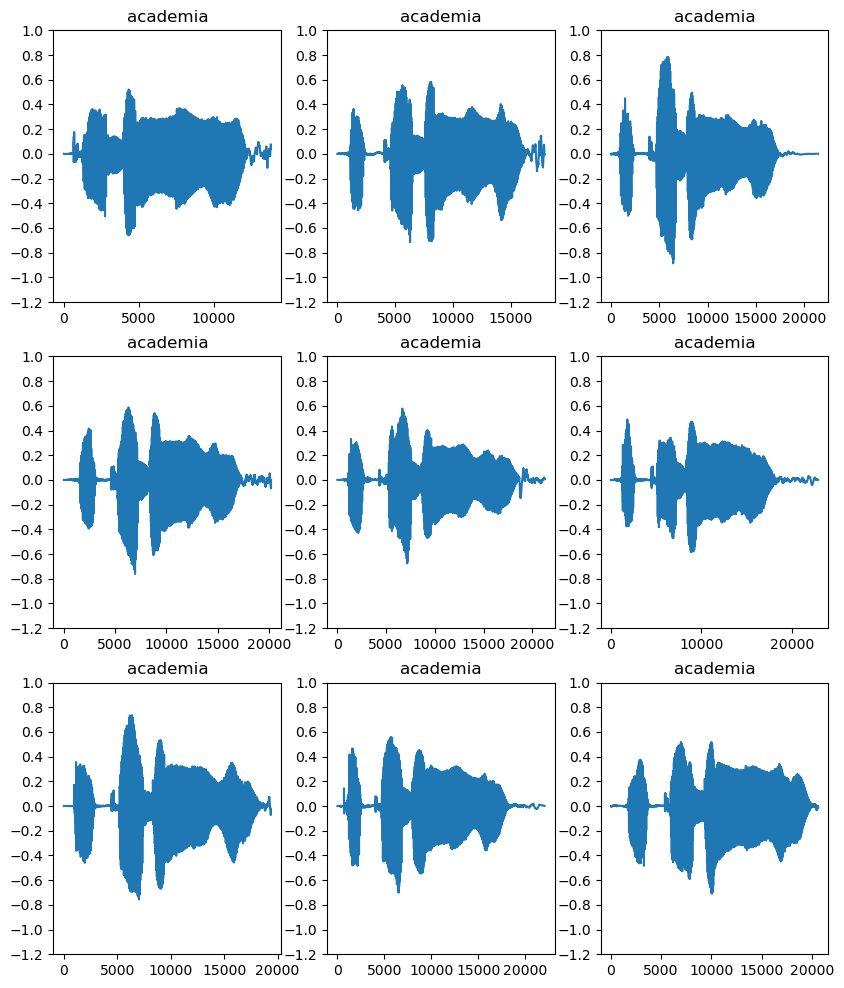

In [17]:
rows = 3
cols = 3
n = rows * cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 12))

for i, (audio, label) in enumerate(val_waveform_ds.take(n)):
  r = i // cols
  c = i % cols
  ax = axes[r][c]
  ax.plot(audio.numpy())
  ax.set_yticks(np.arange(-1.2, 1.2, 0.2))
  label = label.numpy().decode('utf-8')
  ax.set_title(label)

plt.show()

## Converter formas de onda em espectrogramas

In [23]:
def adjust_audio_length(audio, max_samples):
    #audio = tf.squeeze(audio, axis=-1) # Flatten to mono
    # Cut/Slice to max value (length)
    if tf.shape(audio)[0] > max_samples:
        new_audio = audio[:max_samples]
    else:
        # Optional: Pad if shorter than max_samples
        padding = max_samples - tf.shape(audio)[0]
        new_audio = tf.pad(audio, [[0, padding]])
    return new_audio

In [21]:
def get_spectrogram(waveform):
  # Zero-padding for an audio waveform with less than 16,000 samples.
  input_len = 16000
  waveform = waveform[:input_len]
  zero_padding = tf.zeros([16000] - tf.shape(waveform), dtype=tf.float32)
  # Cast the waveform tensors' dtype to float32.
  waveform = tf.cast(waveform, dtype=tf.float32)
  # Concatenate the waveform with `zero_padding`, which ensures all audio
  # clips are of the same length.
  equal_length = tf.concat([waveform, zero_padding], 0)
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(equal_length, frame_length=255, frame_step=128)
  #print("spectrogram: ", spectrogram.shape, spectrogram.shape[-1])
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  #print("spec: ", spectrogram.shape)
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

def get_mfcc(waveform):
    print("waveform: ", waveform.shape)
    specs = get_spectrogram(waveform)
    #batch_size, num_samples, sample_rate = 32, 32000, 16000.0
    sample_rate = 16000
    # A Tensor of [batch_size, num_samples] mono PCM samples in the range [-1, 1].
    if len(specs.shape) > 2:
        assert len(specs.shape) == 3
        specs = tf.squeeze(specs)
    #specs = tf.squeeze(spectrogram)
    
    # Warp the linear scale spectrograms into the mel-scale.
    #num_spectrogram_bins = stfts.shape[-1].value
    num_spectrogram_bins = specs.shape[-1]
    print("num_spectrogram_bins: ", num_spectrogram_bins)
    lower_edge_hertz, upper_edge_hertz, num_mel_bins = 80.0, 7600.0, 80
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(num_mel_bins, 
                                                                        num_spectrogram_bins, 
                                                                        sample_rate, 
                                                                        lower_edge_hertz,
                                                                        upper_edge_hertz)
    print("linear_to_mel_weight_matrix: ", linear_to_mel_weight_matrix.shape)
    mel_spectrograms = tf.tensordot(specs, linear_to_mel_weight_matrix, 1)
    print("mel_spectrograms: ", mel_spectrograms.shape)
    print("specs.shape[:-1]: ", specs.shape[:-1], specs.shape[-1])
    mel_spectrograms.set_shape(specs.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))
    print("mel_spectrograms: ", mel_spectrograms.shape)
    #mel_spectrograms.set_shape(specs.shape[-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))
    print("mel_spectrograms: ", mel_spectrograms.shape)
    # Compute a stabilized log to get log-magnitude mel-scale spectrograms.
    log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)
    print("log_mel_spectrograms: ", log_mel_spectrograms.shape)
    
    # Compute MFCCs from log_mel_spectrograms and take the first 13.
    #mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrograms)[..., :13]
    #print("mfccs: ", mfccs.shape)
    #mfccs = mfccs[tf.newaxis, ...]
    #print("mfccs: ", mfccs.shape)
    return mfccs

def get_log_mel_spectrogram(waveform, sample_rate=16000):
    # Zero-padding for an audio waveform with less than 16,000 samples.
    max_length = 19200
    waveform = adjust_audio_length(waveform, max_length)
    print("waveform.shape: ", waveform.shape)
    #zero_padding = tf.zeros([16000] - tf.shape(waveform), dtype=tf.float32)
    # Cast the waveform tensors' dtype to float32.
    waveform = tf.cast(waveform, dtype=tf.float32)
    # Concatenate the waveform with `zero_padding`, which ensures all audio
    # clips are of the same length.
    #equal_length = tf.concat([waveform, zero_padding], 0)
    # 1. Short-time Fourier Transform (STFT)
    # n_fft e hop_length devem ser pequenos para modelos Tiny (ex: 25ms e 10ms)
    #stfts = tf.signal.stft(equal_length, frame_length=255, frame_step=128)
    stfts = tf.signal.stft(waveform, frame_length=255, frame_step=128)
    
    # 2. Espectrograma de Magnitude
    spectrograms = tf.abs(stfts)
    
    # 3. Mapeamento para Escala Mel
    num_spectrogram_bins = stfts.shape[-1]
    lower_edge_hertz, upper_edge_hertz, num_mel_bins = 80.0, 7600.0, 40
    
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins, num_spectrogram_bins, sample_rate, 
        lower_edge_hertz, upper_edge_hertz)
    
    mel_spectrograms = tf.tensordot(spectrograms, linear_to_mel_weight_matrix, 1)
    mel_spectrograms.set_shape(spectrograms.shape[:-1].concatenate(
        linear_to_mel_weight_matrix.shape[-1:]))

    # 4. Compressão Logarítmica (estabilizada com eps)
    log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)
    
    return log_mel_spectrograms[..., tf.newaxis] # Retorna (Frames, Bins, 1)

initial waveform:  tf.Tensor(
[-0.00033569 -0.0005188  -0.00033569 ...  0.06259155  0.06939697
  0.04260254], shape=(13819,), dtype=float32)
waveform.shape:  (16000,)
last shape:  (16000,)


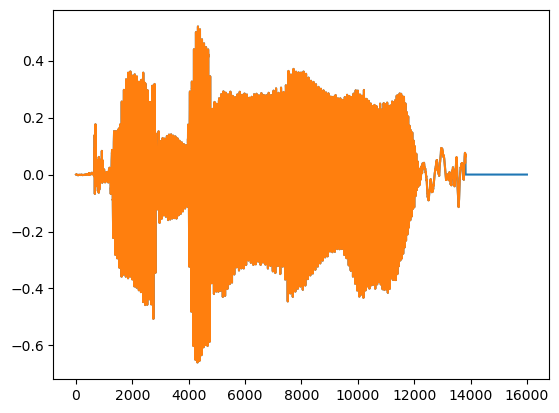

In [26]:
for waveform, label in val_waveform_ds.take(1):
    print("initial waveform: ", waveform)
    max_length = 16000
    new_waveform = adjust_audio_length(waveform, max_length)
    print("waveform.shape: ", new_waveform.shape)
    # Cast the waveform tensors' dtype to float32.
    new_waveform = tf.cast(new_waveform, dtype=tf.float32)
    print("last shape: ", new_waveform.shape)
    
    plt.plot(new_waveform)
    plt.plot(waveform)

In [27]:
for waveform, label in val_waveform_ds.take(1):
  label = label.numpy().decode('utf-8')
  spectrogram = get_spectrogram(waveform)

print('Label:', label)
print('Waveform shape:', waveform.shape)
print('Spectrogram shape:', spectrogram.shape)
print('Audio playback')
display.display(display.Audio(waveform, rate=16000, normalize=False))

Label: academia
Waveform shape: (13819,)
Spectrogram shape: (124, 129, 1)
Audio playback


In [29]:
for waveform, label in val_waveform_ds.take(2):
  label = label.numpy().decode('utf-8')
  #spectrogram = get_spectrogram(waveform)
  log_mel = get_log_mel_spectrogram(waveform)

print('Label:', label)
print('Waveform shape:', waveform.shape)
print('Log Mel-spectrogram shape:', log_mel.shape)
print('Audio playback')
display.display(display.Audio(waveform, rate=16000, normalize=False))

waveform.shape:  (19200,)
waveform.shape:  (19200,)
Label: academia
Waveform shape: (17944,)
Log Mel-spectrogram shape: (149, 40, 1)
Audio playback


In [30]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

def plot_log_mel_spectrogram(log_mel, ax):
  if len(log_mel.shape) > 2:
    assert len(log_mel.shape) == 3
    log_mel = np.squeeze(log_mel, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_mel = log_mel.T
  height = log_mel.shape[0]
  width = log_mel.shape[1]
  X = np.linspace(0, np.size(log_mel), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_mel)

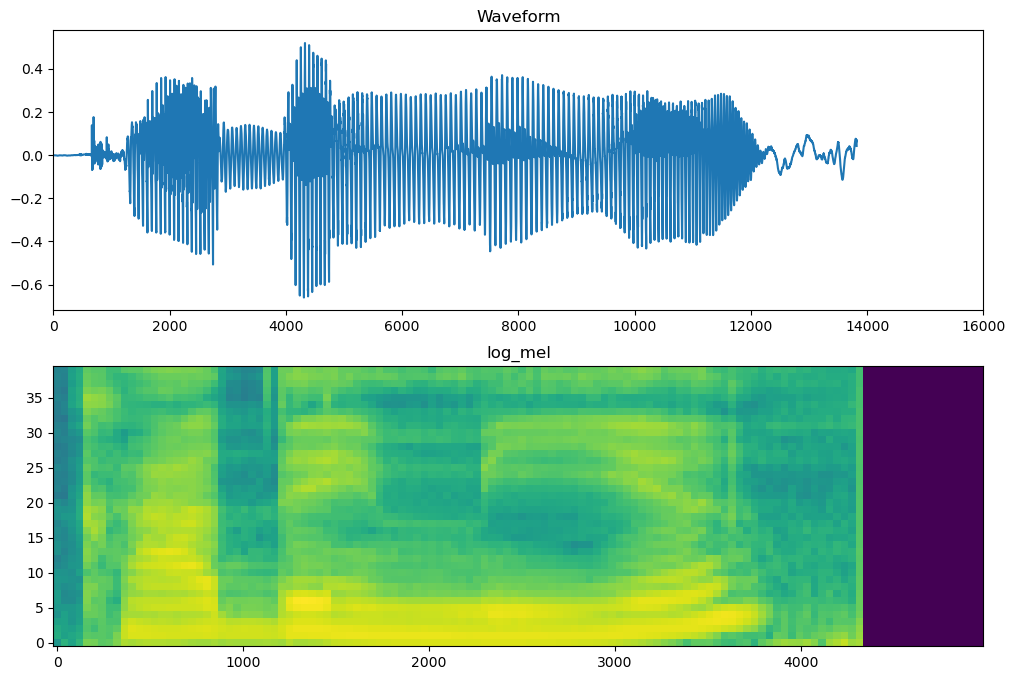

In [60]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

# plot_spectrogram(spectrogram.numpy(), axes[1])
# axes[1].set_title('Spectrogram')
# plt.show()

plot_log_mel_spectrogram(log_mel.numpy(), axes[1])
axes[1].set_title('log_mel')
plt.show()

Mapeie get_spectrogram_and_label_id entre os elementos do conjunto de dados com Dataset.map :

In [31]:
LABELS = list(df["words"].unique())
LABELS

['academia',
 'aeroporto',
 'casa',
 'cinema',
 'escola',
 'faculdade',
 'farmacia',
 'hospital',
 'mercado',
 'trabalho']

In [32]:
def get_spectrogram_and_label_id(audio, label):
  print(audio)
  spectrogram = get_spectrogram(audio)
  print("spectrogram f: ", spectrogram)
  label_id = tf.argmax(label == LABELS)
  return spectrogram, label_id

def get_log_mel_spectrogram_and_label_id(audio, label):
  log_mel_spec = get_log_mel_spectrogram(audio)
  print(log_mel_spec.shape)
  label_id = tf.argmax(label == LABELS)
  return log_mel_spec, label_id

In [33]:
#val_spectrogram_ds = val_waveform_ds.map(map_func=get_spectrogram_and_label_id, num_parallel_calls=AUTOTUNE)
val_log_mel_ds = val_waveform_ds.map(map_func=get_log_mel_spectrogram_and_label_id, num_parallel_calls=AUTOTUNE)

waveform.shape:  (None,)
(None, 40, 1)


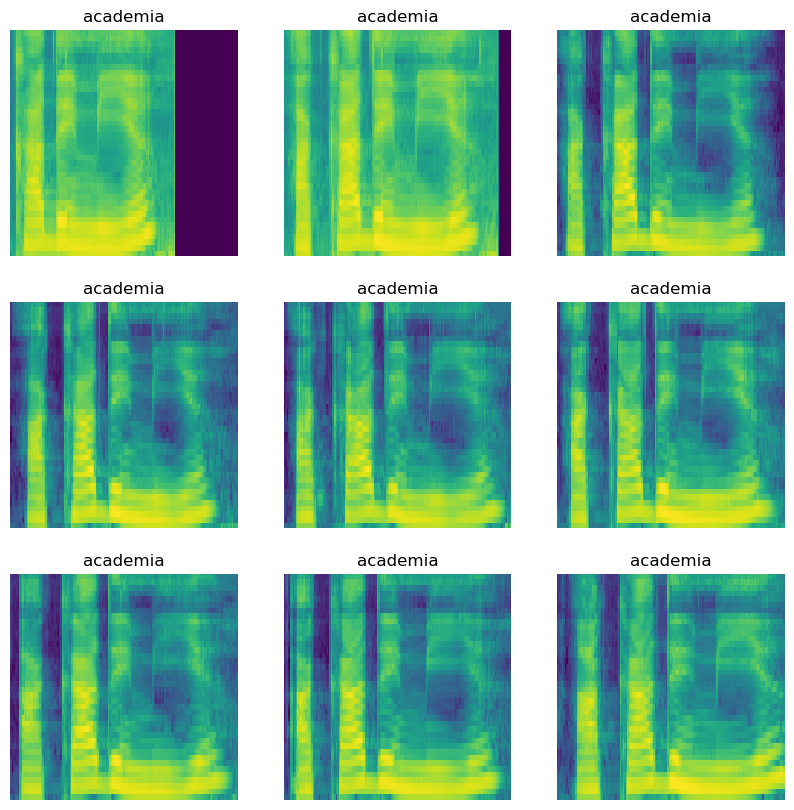

In [34]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

for i, (log_mel, label_id) in enumerate(val_log_mel_ds.take(n)):
  r = i // cols
  c = i % cols
  ax = axes[r][c]
  plot_log_mel_spectrogram(log_mel.numpy(), ax)
  ax.set_title(LABELS[label_id.numpy()])
  ax.axis('off')

plt.show()

## Construir e treinar o modelo

In [35]:
def preprocess_dataset(files, labels):
  files_ds = tf.data.Dataset.from_tensor_slices((files, labels))
  output_ds = files_ds.map(map_func=get_waveform_and_label, num_parallel_calls=AUTOTUNE)
  output_ds = output_ds.map(map_func=get_log_mel_spectrogram_and_label_id, num_parallel_calls=AUTOTUNE)
  return output_ds

In [36]:
train_ds = preprocess_dataset(train_files, train_labels)
val_ds = preprocess_dataset(val_files, val_labels)
test_ds = preprocess_dataset(test_files, test_labels)

waveform.shape:  (None,)
(None, 40, 1)
waveform.shape:  (None,)
(None, 40, 1)
waveform.shape:  (None,)
(None, 40, 1)


In [37]:
batch_size = 64
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)

Adicione as operações Dataset.cache e Dataset.prefetch para reduzir a latência de leitura durante o treinamento do modelo:

In [38]:
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Para o modelo, você usará uma rede neural convolucional simples (CNN), pois transformou os arquivos de áudio em imagens de espectrograma.

Seu modelo tf.keras.Sequential usará as seguintes camadas de pré-processamento Keras:

- tf.keras.layers.Resizing : para reduzir a amostra da entrada para permitir que o modelo treine mais rápido.
- tf.keras.layers.Normalization : para normalizar cada pixel da imagem com base em sua média e desvio padrão.

Para a camada de Normalization , seu método de adapt precisaria primeiro ser chamado nos dados de treinamento para calcular estatísticas agregadas (ou seja, a média e o desvio padrão).

In [39]:
# for spectrogram, _ in val_spectrogram_ds.take(1):
#   input_shape = spectrogram.shape

for log_mel, _ in val_ds.unbatch().take(2):
    input_shape = log_mel.shape
    
print('Input shape:', input_shape)
num_labels = len(LABELS)

Input shape: (149, 40, 1)


2026-04-22 19:59:56.802475: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [40]:
# for spectrogram, _ in val_spectrogram_ds.take(1):
#   input_shape = spectrogram.shape

for log_mel, _ in val_log_mel_ds.take(3):
    input_shape = log_mel.shape
    
print('Input shape:', input_shape)
num_labels = len(LABELS)

Input shape: (149, 40, 1)


In [41]:
# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
#norm_layer.adapt(data=val_spectrogram_ds.map(map_func=lambda spec, label: spec))
norm_layer.adapt(data=val_ds.unbatch().map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 32, 32, 1)         0         
                                                                 
 normalization (Normalizati  (None, 32, 32, 1)         3         
 on)                                                             
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 14, 14, 64)        0

In [49]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

In [51]:
EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/20
44/44 [==============================] - 2s 46ms/step - loss: 0.8793 - accuracy: 0.7218 - val_loss: 1.7744 - val_accuracy: 0.5875
Epoch 2/20
44/44 [==============================] - 2s 45ms/step - loss: 0.7203 - accuracy: 0.7786 - val_loss: 1.4312 - val_accuracy: 0.6300
Epoch 3/20
44/44 [==============================] - 2s 45ms/step - loss: 0.7855 - accuracy: 0.7571 - val_loss: 2.0068 - val_accuracy: 0.5925
Epoch 4/20
44/44 [==============================] - 2s 45ms/step - loss: 0.7600 - accuracy: 0.7650 - val_loss: 0.8304 - val_accuracy: 0.7950
Epoch 5/20
44/44 [==============================] - 2s 46ms/step - loss: 0.5383 - accuracy: 0.8329 - val_loss: 0.7139 - val_accuracy: 0.8225
Epoch 6/20
44/44 [==============================] - 2s 44ms/step - loss: 0.4094 - accuracy: 0.8729 - val_loss: 0.6614 - val_accuracy: 0.8375
Epoch 7/20
44/44 [==============================] - 2s 44ms/step - loss: 0.3079 - accuracy: 0.9046 - val_loss: 0.6359 - val_accuracy: 0.8525
Epoch 8/20
44

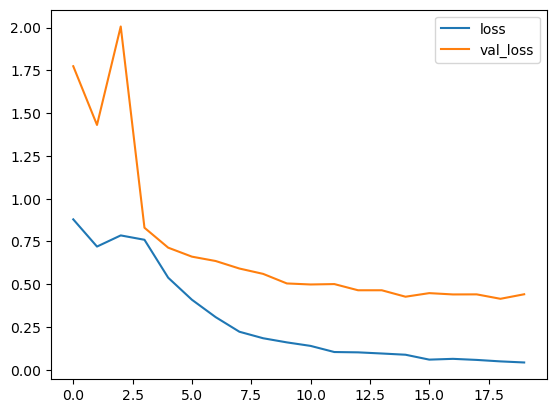

In [52]:
def plot_curve(metrics):
    plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
    plt.legend(['loss', 'val_loss'])
    plt.savefig("curve.png")
    plt.show()

metrics = history.history
plot_curve(metrics)
# plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
# plt.legend(['loss', 'val_loss'])
# plt.show()

In [45]:
def get_test_set(test_ds):
    test_audio = []
    test_labels = []
    
    for audio, label in test_ds:
      test_audio.append(audio.numpy())
      test_labels.append(label.numpy())
    
    test_audio = np.array(test_audio)
    test_labels = np.array(test_labels)
    return test_audio, test_labels

In [53]:
test_audio, test_labels = get_test_set(test_ds)

In [47]:
def get_results(test_audio, test_labels):
    y_pred = np.argmax(model.predict(test_audio), axis=1)
    y_true = test_labels
    
    test_acc = sum(y_pred == y_true) / len(y_true)
    print(f'Test set accuracy: {test_acc:.0%}')
    return y_true, y_pred

In [54]:
y_true, y_pred = get_results(test_audio, test_labels)

25/25 [==============================] - 0s 8ms/step
Test set accuracy: 97%


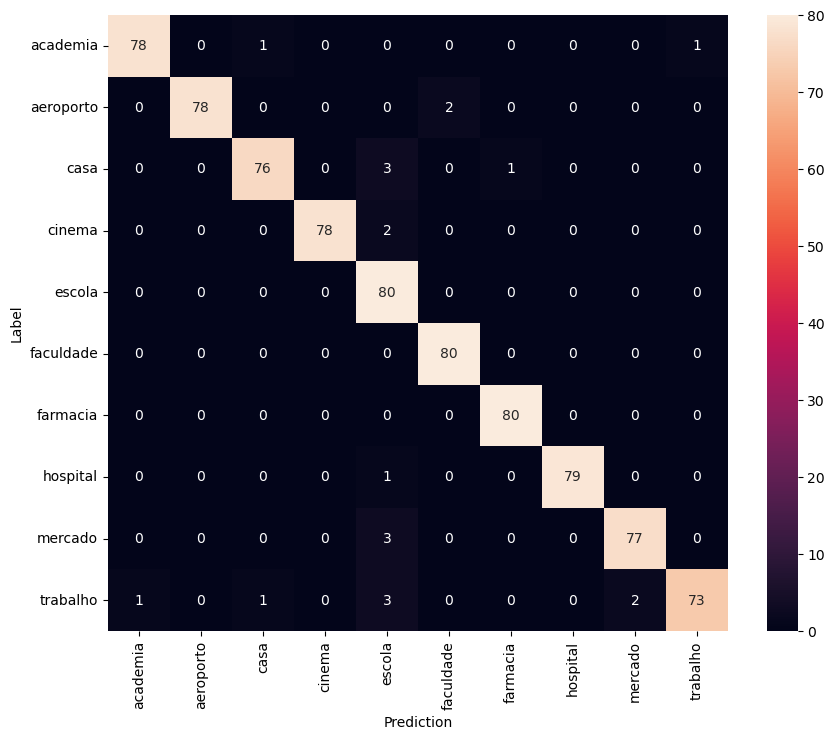

In [55]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=LABELS,
            yticklabels=LABELS,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

## Select results by gender

In [64]:
# def selet_results_bey_gender(df_test, x):
#     df_test_x = df_test[df_test["genders"] == x]
#     test_files_x, test_labels_x = get_files(df_test_x)
#     test_audio_x, test_labels_x = get_test_set(preprocess_dataset(test_files_x, test_labels_x))
#     y_true_x, y_pred_x = get_results(test_audio_x, test_labels_x)

In [56]:
df_test_F = df_test[df_test["genders"] == "F"]
df_test_M = df_test[df_test["genders"] == "M"]

In [57]:
test_files_F, test_labels_F = get_files(df_test_F)
test_files_M, test_labels_M = get_files(df_test_M)

In [58]:
# test_ds_fem = preprocess_dataset(test_files_F, test_labels_F)
# test_ds_male = preprocess_dataset(test_files_M, test_labels_M)

test_audio_female, test_labels_female = get_test_set(preprocess_dataset(test_files_F, test_labels_F))
test_audio_male, test_labels_male = get_test_set(preprocess_dataset(test_files_M, test_labels_M))

waveform.shape:  (None,)
(None, 40, 1)
waveform.shape:  (None,)
(None, 40, 1)


In [59]:
y_true_F, y_pred_F = get_results(test_audio_female, test_labels_female)

13/13 [==============================] - 0s 9ms/step
Test set accuracy: 98%


In [60]:
y_true_M, y_pred_M = get_results(test_audio_male, test_labels_male)

13/13 [==============================] - 0s 9ms/step
Test set accuracy: 96%


In [65]:
#selet_results_bey_gender(df_test, "F")

13/13 [==============================] - 0s 10ms/step
Test set accuracy: 91%


## Executar inferência em um arquivo de áudio

In [ ]:
path_test = df_test["filepaths"][799]
word_test = [9]
path_test, word_test

In [ ]:
sample_ds = preprocess_dataset(str(path_test), word_test)

In [ ]:
for spectrogram, label in sample_ds.batch(1):
  prediction = model(spectrogram)
  plt.bar(LABELS, tf.nn.softmax(prediction[0]))
  plt.title(f'Predictions for "{LABELS[label[0]]}"')
  plt.show()

Reference: 
- https://www.tensorflow.org/tutorials/audio/simple_audio?hl=pt-br
- https://medium.com/@oluyaled/audio-classification-using-deep-learning-and-tensorflow-a-step-by-step-guide-5327467ee9ab
- https://www.tensorflow.org/api_docs/python/tf/signal/mfccs_from_log_mel_spectrograms
- https://www.tensorflow.org/api_docs/python/tf/signal/stft